In [184]:
import pandas as pd
import matplotlib.pyplot as plt

import os

In [185]:
!ls ../pruebas/ablacion/C1D_C2D/

train_log.csv  weights.pmt


# Load Data

In [186]:
import os
import pandas as pd
import numpy as np
import seaborn as sns

ABLATIONS_PATH = '../pruebas/crossFamily/weights/RNaseP/'
CROSSFAMILY_PATH = '../pruebas/crossFamily/weights/'

# Listado de ablations y homologies
ablations = os.listdir(ABLATIONS_PATH)
print(f"Ablations: {ablations}")

cross_families = os.listdir(CROSSFAMILY_PATH)
print(f"cross families: {cross_families}")

# Inicializamos una lista para almacenar los DataFrames de los archivos train_log.csv
train_logs = []

# Recorrer cada crossFamily y ablation para buscar los archivos train_log.csv
for crossFamily in cross_families:
    for ablation in ablations:
        # Ruta del subdirectorio donde se encuentran los archivos train_log.csv
        train_file_path = os.path.join(CROSSFAMILY_PATH, crossFamily, ablation)
        
        # Verificamos si el directorio existe
        if os.path.isdir(train_file_path):
            # Verificar si el archivo 'train_log.csv' existe en el directorio
            train_file = 'train_log.csv'
            full_path = os.path.join(train_file_path, train_file)
            # Si el archivo existe, lo leemos
            if os.path.exists(full_path):
                try:
                    df = pd.read_csv(full_path)
                    
                    # Agregar columnas de 'ablation' y 'crossFamily'
                    df['ablation'] = ablation
                    df['crossFamily'] = crossFamily
                    
                    # Agregar el DataFrame a la lista
                    train_logs.append(df)
                    print(f"Successfully loaded {full_path}")
                except Exception as e:
                    print(f"Error loading {full_path}: {e}")

# Combinar todos los DataFrames en uno solo
if train_logs:
    df_logs = pd.concat(train_logs, ignore_index=True)
    print(f"Total rows in combined DataFrame: {df_logs.shape[0]}")
else:
    df_logs = pd.DataFrame()  # DataFrame vacío si no hay archivos cargados 


Ablations: ['C1D_C2D', 'sincfold', 'no_ResNet2d', '1ResNet2d', 'no_ResNet1d']
cross families: ['tRNA', 'RNaseP', 'telomerase']
Successfully loaded ../pruebas/crossFamily/weights/tRNA/C1D_C2D/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/tRNA/no_ResNet2d/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/tRNA/1ResNet2d/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/tRNA/no_ResNet1d/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/RNaseP/C1D_C2D/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/RNaseP/no_ResNet2d/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/RNaseP/1ResNet2d/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/RNaseP/no_ResNet1d/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/telomerase/C1D_C2D/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/telomerase/no_ResNet2d/train_log.csv
Successfully loaded ../pruebas/crossFamily/weight

# Analisis de error

## Validacion random general

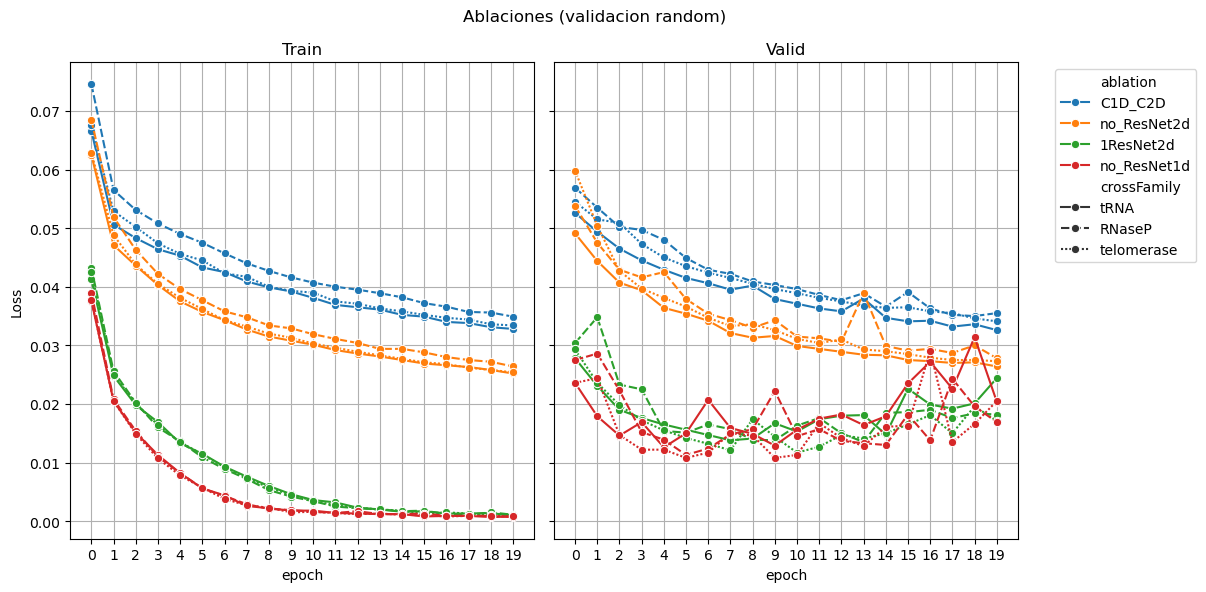

In [187]:
fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True)

# .query('ablation not in ["1ResNet2d", "no_ResNet1d"]')
sns.lineplot(data=df_logs, x='epoch' ,y='train_loss',hue='ablation', style='crossFamily', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=df_logs, x='epoch' ,y='valid_loss',hue='ablation', style='crossFamily', marker='o', ax=axes[1])
for ax in axes: ax.grid()
for ax in axes: ax.set_xticks(range(20))
axes[0].set_ylabel('Loss')
axes[0].set_title('Train')
axes[1].set_title('Valid')
axes[1].legend(bbox_to_anchor=(1.4,1))
fig.suptitle('Ablaciones (validacion random)')
fig.tight_layout()
plt.show()

Observando el error: 
- los modelos mas complejos alcanzan menor error.
- las ablaciones se diferencian en la epoch 1.
- el error de validacion de los modelos sin capa 2d es decreciente.
- el error de validacion de los modelos con capas 2d luego de 4/5 epoch dejan de disminuir.

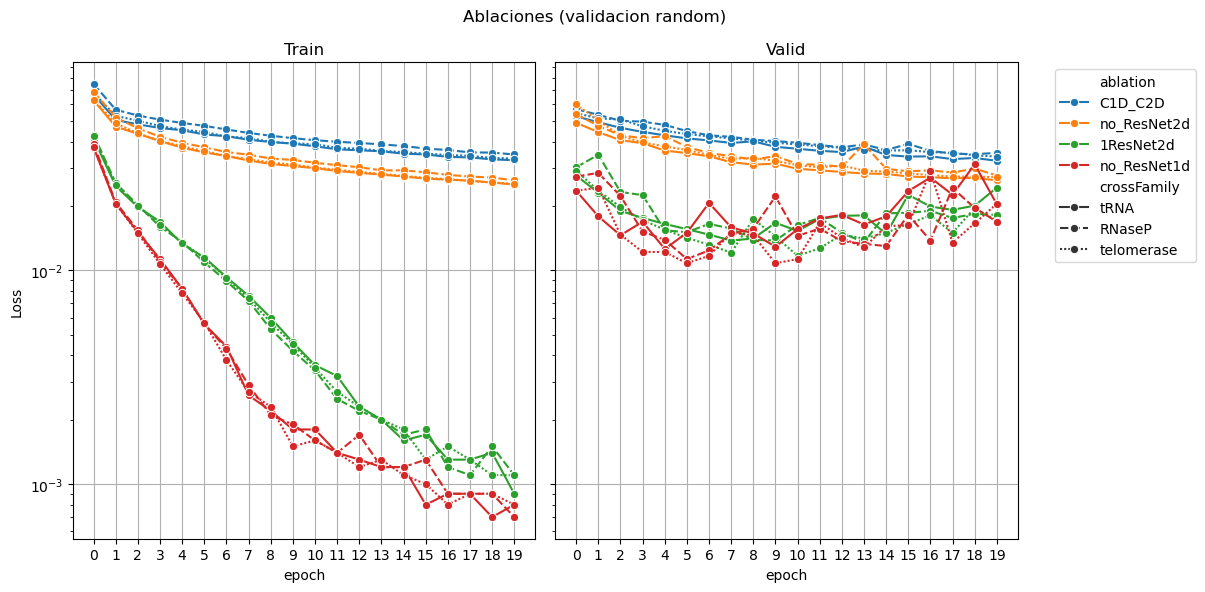

In [188]:
fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True)

# .query('ablation not in ["1ResNet2d", "no_ResNet1d"]')
sns.lineplot(data=df_logs, x='epoch' ,y='train_loss',hue='ablation', style='crossFamily', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=df_logs, x='epoch' ,y='valid_loss',hue='ablation', style='crossFamily', marker='o', ax=axes[1])
for ax in axes: ax.grid()
for ax in axes: ax.set_xticks(range(20))
for ax in axes: ax.set_yscale('log')

axes[0].set_ylabel('Loss')
axes[0].set_title('Train')
axes[1].set_title('Valid')
axes[1].legend(bbox_to_anchor=(1.4,1))
fig.suptitle('Ablaciones (validacion random)')
fig.tight_layout()
plt.show()

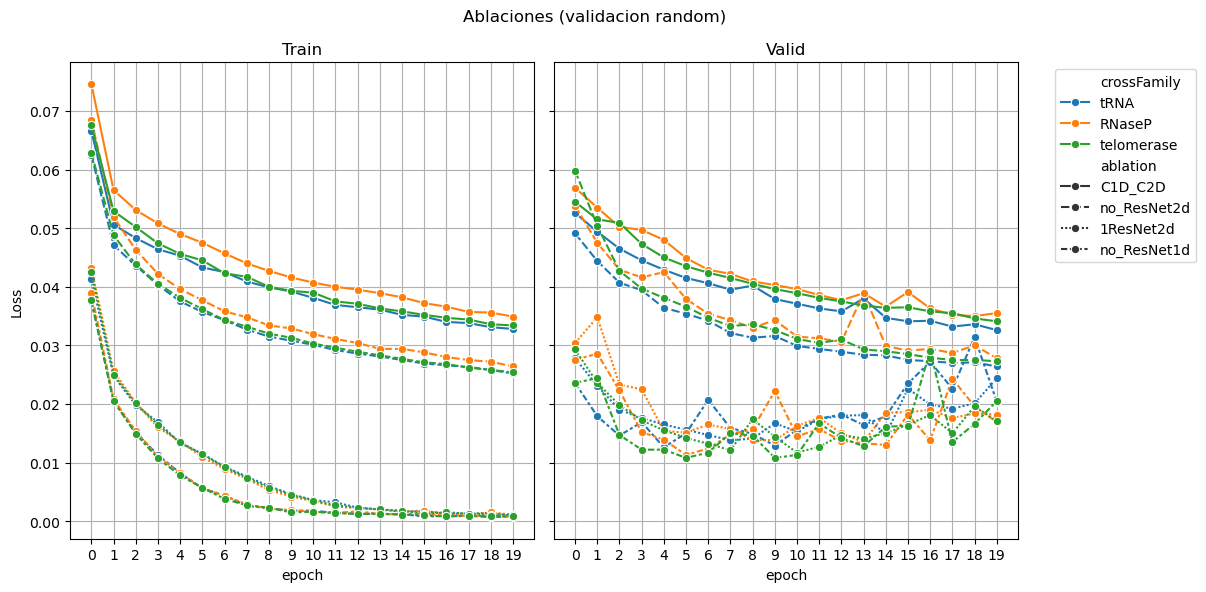

In [189]:
fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True)
sns.lineplot(data=df_logs, x='epoch' ,y='train_loss',hue='crossFamily', style='ablation', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=df_logs, x='epoch' ,y='valid_loss',hue='crossFamily', style='ablation', marker='o', ax=axes[1]) 
for ax in axes: ax.grid()
for ax in axes: ax.set_xticks(range(20))
axes[0].set_ylabel('Loss')
axes[0].set_title('Train')
axes[1].set_title('Valid')
axes[1].legend(bbox_to_anchor=(1.4,1))
fig.suptitle('Ablaciones (validacion random)')
fig.tight_layout()
plt.show()

## Validacion Random individual

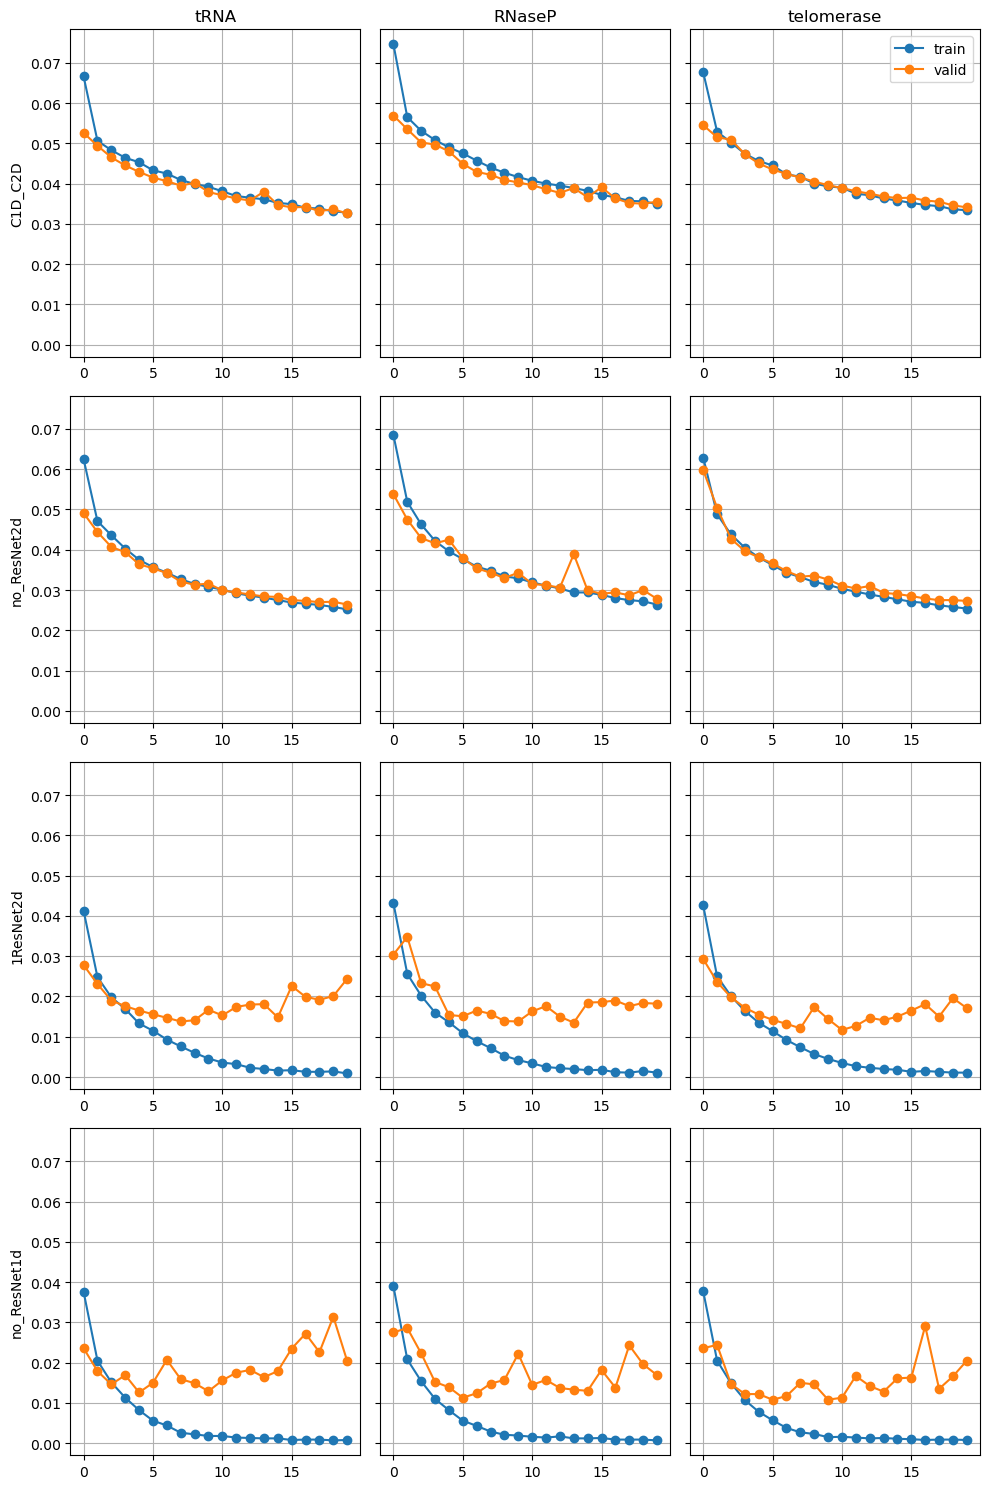

In [190]:
data = df_logs
ab = data.ablation.unique()
cf = data.crossFamily.unique()
fig, axes = plt.subplots(len(ab),len(cf), figsize=(10,15), sharey=True)
for i,a in enumerate(ab):
    axes[i,0].set_ylabel(a)
    for j,f in enumerate(cf):
        axes[0,j].set_title(f)
        d = data.query('ablation == @a & crossFamily == @f')
        axes[i,j].plot(d.epoch, d.train_loss, marker='o', label='train')
        axes[i,j].plot(d.epoch, d.valid_loss, marker='o', label='valid') 
        axes[i,j].grid()
axes[0,-1].legend()        
fig.tight_layout()

Las ablaciones con capas 2d tienen error de validacion mayor. Podria considerarse que a 5 epoch empiezaz a crecer en estos casos.

## Train con test en validacion 

In [191]:
import os
import pandas as pd
import numpy as np
import seaborn as sns

ABLATIONS_PATH = '../pruebas/crossFamily/weights/RNaseP/'
CROSSFAMILY_PATH = '../pruebas/crossFamily/weights/'

# Listado de ablations y homologies
ablations = os.listdir(ABLATIONS_PATH)
print(f"Ablations: {ablations}")

cross_families = os.listdir(CROSSFAMILY_PATH)
print(f"cross families: {cross_families}")

# Inicializamos una lista para almacenar los DataFrames de los archivos train_log.csv
train_logs = []

# Recorrer cada crossFamily y ablation para buscar los archivos train_log.csv
for crossFamily in cross_families:
    for ablation in ablations:
        # Ruta del subdirectorio donde se encuentran los archivos train_log.csv
        train_file_path = os.path.join(CROSSFAMILY_PATH, crossFamily, ablation, 'valid_with_test')
        
        # Verificamos si el directorio existe
        if os.path.isdir(train_file_path):
            # Verificar si el archivo 'train_log.csv' existe en el directorio
            train_file = 'train_log.csv'
            full_path = os.path.join(train_file_path, train_file)
            
            # Si el archivo existe, lo leemos
            if os.path.exists(full_path):
                try:
                    df = pd.read_csv(full_path)
                    
                    # Agregar columnas de 'ablation' y 'crossFamily'
                    df['ablation'] = ablation
                    df['crossFamily'] = crossFamily
                    
                    # Agregar el DataFrame a la lista
                    train_logs.append(df)
                    print(f"Successfully loaded {full_path}")
                except Exception as e:
                    print(f"Error loading {full_path}: {e}")

# Combinar todos los DataFrames en uno solo
if train_logs:
    train_log_with_valid = pd.concat(train_logs, ignore_index=True)
    print(f"Total rows in combined DataFrame: {train_log_with_valid.shape[0]}")
else:
    train_log_with_valid = pd.DataFrame()  # DataFrame vacío si no hay archivos cargados 


Ablations: ['C1D_C2D', 'sincfold', 'no_ResNet2d', '1ResNet2d', 'no_ResNet1d']
cross families: ['tRNA', 'RNaseP', 'telomerase']
Successfully loaded ../pruebas/crossFamily/weights/tRNA/C1D_C2D/valid_with_test/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/tRNA/sincfold/valid_with_test/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/tRNA/no_ResNet2d/valid_with_test/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/RNaseP/C1D_C2D/valid_with_test/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/RNaseP/sincfold/valid_with_test/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/RNaseP/no_ResNet2d/valid_with_test/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/telomerase/C1D_C2D/valid_with_test/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/telomerase/sincfold/valid_with_test/train_log.csv
Successfully loaded ../pruebas/crossFamily/weights/telomerase/no_ResNet2d/valid_with_test/tr

In [192]:
train_log_with_valid['epoch'].astype(int)

0       0
1       1
2       2
3       3
4       4
       ..
175    15
176    16
177    17
178    18
179    19
Name: epoch, Length: 180, dtype: int64

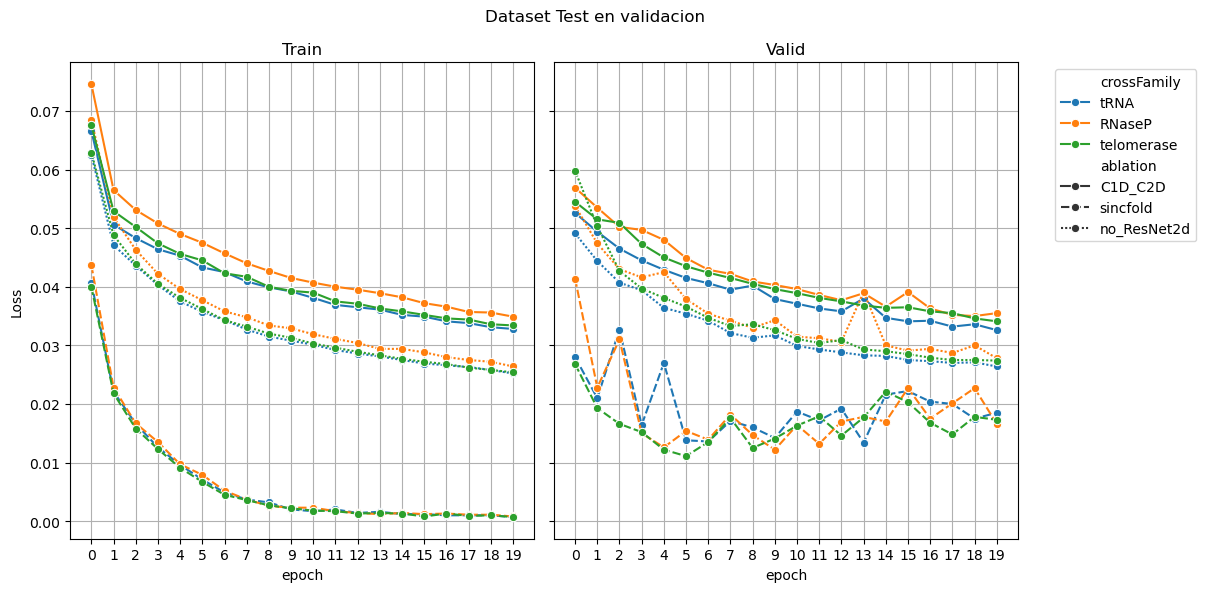

In [193]:
fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True)
sns.lineplot(data=train_log_with_valid, x='epoch' ,y='train_loss',hue='crossFamily', style='ablation', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=train_log_with_valid, x='epoch' ,y='valid_loss',hue='crossFamily', style='ablation', marker='o', ax=axes[1])
for ax in axes: ax.grid()
for ax in axes: ax.set_xticks(range(20))
axes[0].set_ylabel('Loss')
axes[0].set_title('Train')
axes[1].set_title('Valid')
axes[1].legend(bbox_to_anchor=(1.4,1))
fig.suptitle('Dataset Test en validacion')
fig.tight_layout()
plt.show()

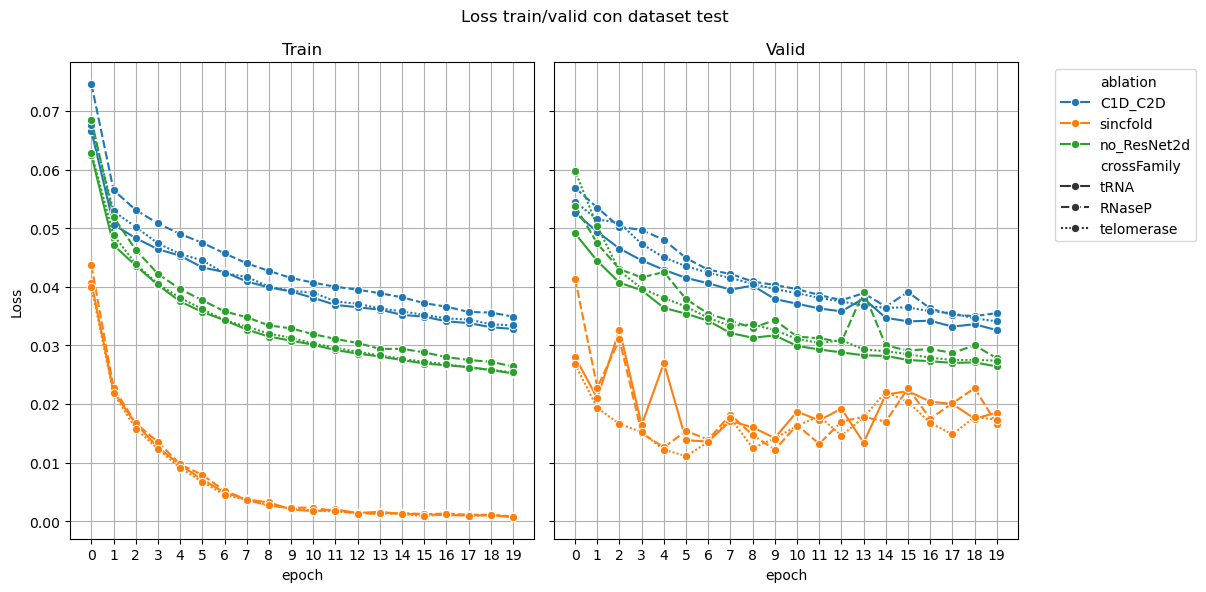

In [194]:
fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True)
sns.lineplot(data=train_log_with_valid, x='epoch' ,y='train_loss',hue='ablation', style='crossFamily', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=train_log_with_valid, x='epoch' ,y='valid_loss',hue='ablation', style='crossFamily', marker='o', ax=axes[1])
for ax in axes: ax.grid()
for ax in axes: ax.set_xticks(range(20))
axes[0].set_ylabel('Loss')
axes[0].set_title('Train')
axes[1].set_title('Valid')
axes[1].legend(bbox_to_anchor=(1.4,1))

fig.suptitle('Loss train/valid con dataset test')
fig.tight_layout()
plt.show()

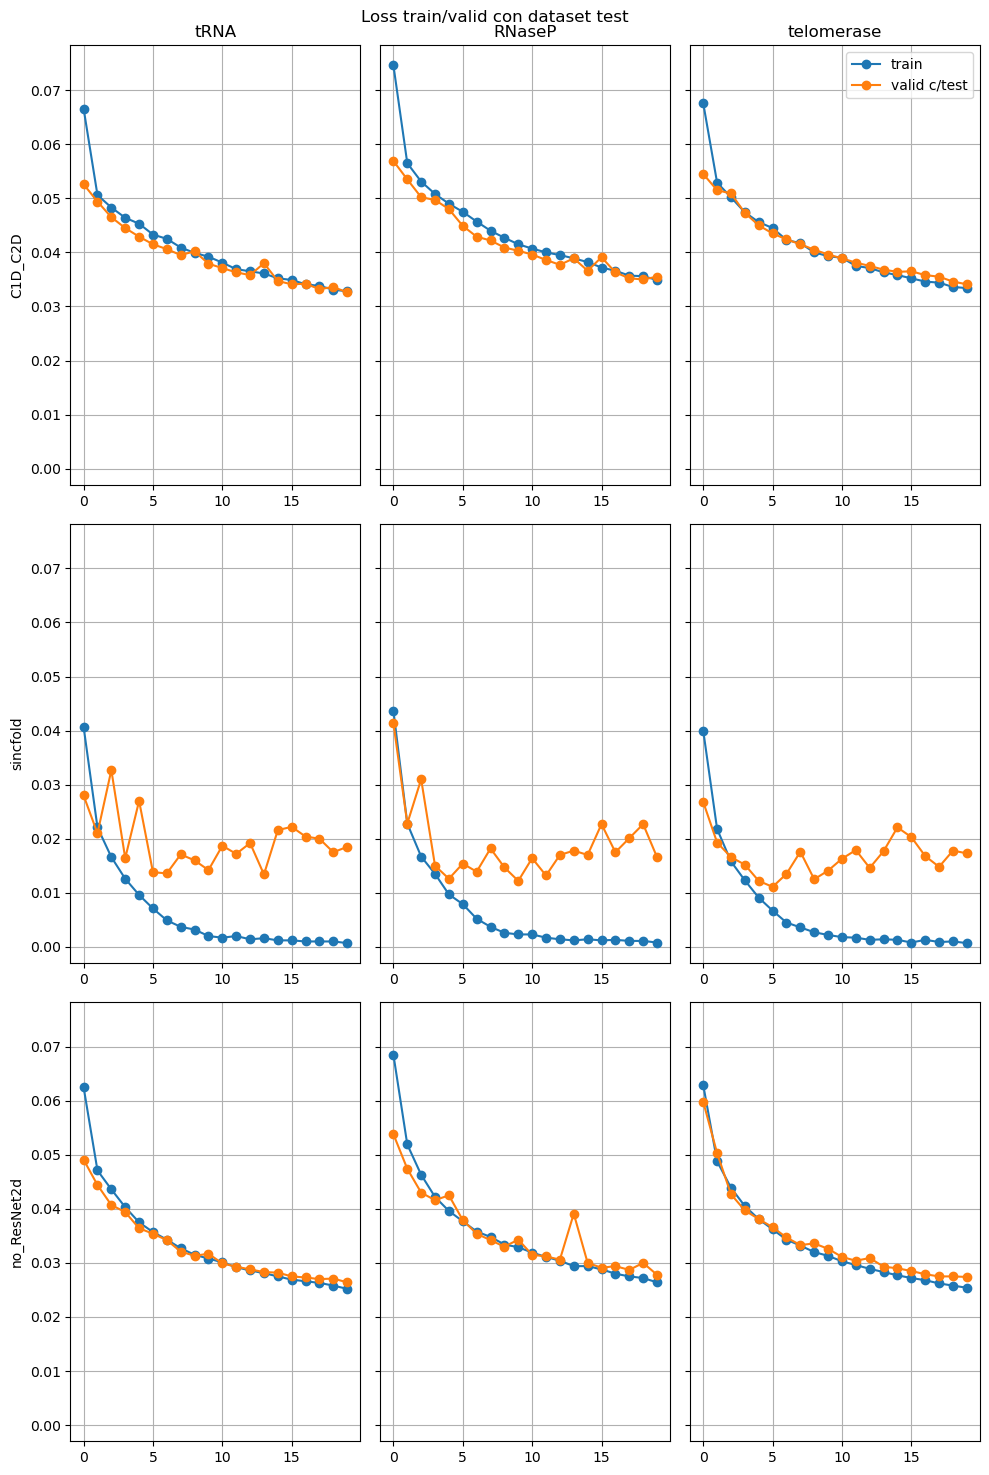

In [195]:
data = train_log_with_valid
ab = data.ablation.unique()
cf = data.crossFamily.unique()
fig, axes = plt.subplots(len(ab),len(cf), figsize=(10,15), sharey=True)
for i,a in enumerate(ab):
    axes[i,0].set_ylabel(a)
    for j,f in enumerate(cf):
        axes[0,j].set_title(f)
        d = data.query('ablation == @a & crossFamily == @f')
        axes[i,j].plot(d.epoch, d.train_loss, marker='o', label='train')
        axes[i,j].plot(d.epoch, d.valid_loss, marker='o', label='valid c/test')
        axes[i,j].grid()
axes[0,-1].legend()        
fig.suptitle('Loss train/valid con dataset test')
fig.tight_layout()

## Agrego a grafica train random el entrenamiento del sincfold (con valid=test)

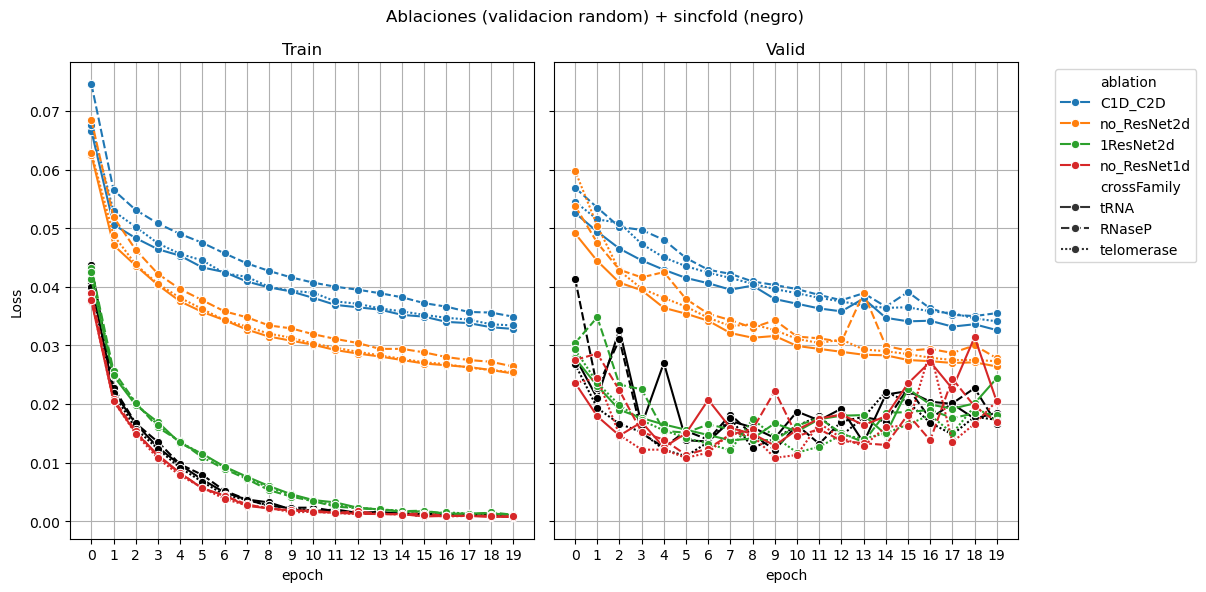

In [196]:
fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True)

# .query('ablation not in ["1ResNet2d", "no_ResNet1d"]')
sns.lineplot(data=train_log_with_valid.query('ablation == "sincfold"'), x='epoch' ,y='train_loss', style='crossFamily',color='black', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=train_log_with_valid.query('ablation == "sincfold"'), x='epoch' ,y='valid_loss', style='crossFamily',color='black', marker='o', ax=axes[1], legend=None)
sns.lineplot(data=df_logs, x='epoch' ,y='train_loss',hue='ablation', style='crossFamily', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=df_logs, x='epoch' ,y='valid_loss',hue='ablation', style='crossFamily', marker='o', ax=axes[1])

for ax in axes: ax.grid()
for ax in axes: ax.set_xticks(range(20))
axes[0].set_ylabel('Loss')
axes[0].set_title('Train')
axes[1].set_title('Valid')
axes[1].legend(bbox_to_anchor=(1.4,1))
fig.suptitle('Ablaciones (validacion random) + sincfold (negro)')
fig.tight_layout()
plt.show()

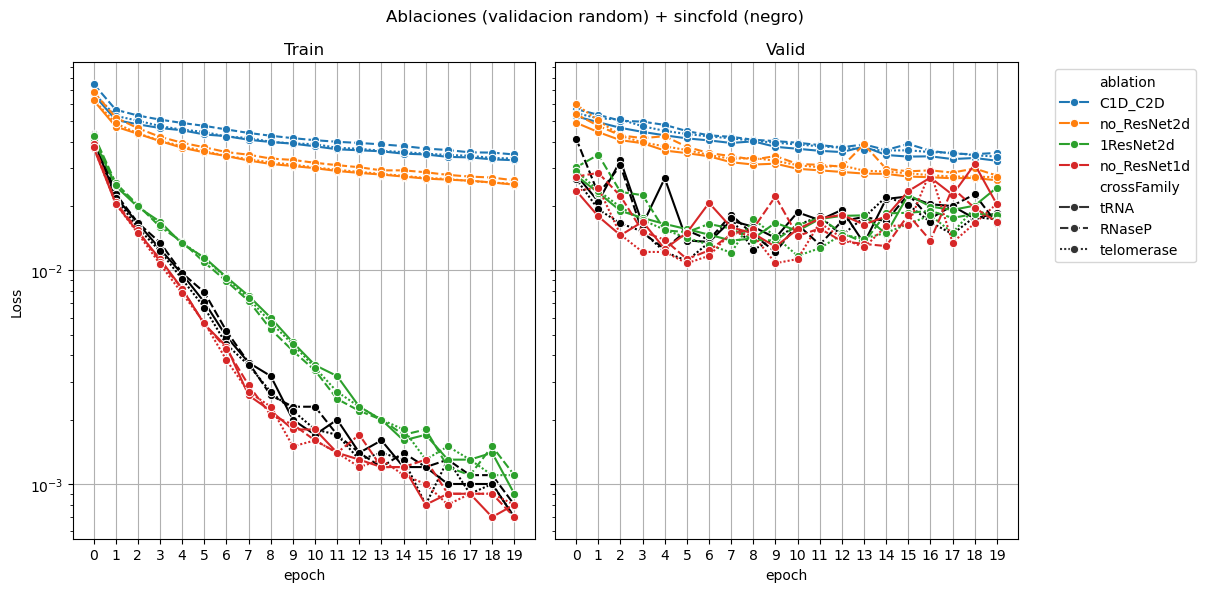

In [197]:
fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True)

# .query('ablation not in ["1ResNet2d", "no_ResNet1d"]')
sns.lineplot(data=train_log_with_valid.query('ablation == "sincfold"'), x='epoch' ,y='train_loss', style='crossFamily',color='black', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=train_log_with_valid.query('ablation == "sincfold"'), x='epoch' ,y='valid_loss', style='crossFamily',color='black', marker='o', ax=axes[1], legend=None)
sns.lineplot(data=df_logs, x='epoch' ,y='train_loss',hue='ablation', style='crossFamily', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=df_logs, x='epoch' ,y='valid_loss',hue='ablation', style='crossFamily', marker='o', ax=axes[1])

for ax in axes: ax.set_yscale('log')
for ax in axes: ax.grid()
for ax in axes: ax.set_xticks(range(20))
axes[0].set_ylabel('Loss')
axes[0].set_title('Train')
axes[1].set_title('Valid')
axes[1].legend(bbox_to_anchor=(1.4,1))
fig.suptitle('Ablaciones (validacion random) + sincfold (negro)')
fig.tight_layout()
plt.show()

## Analisis F1

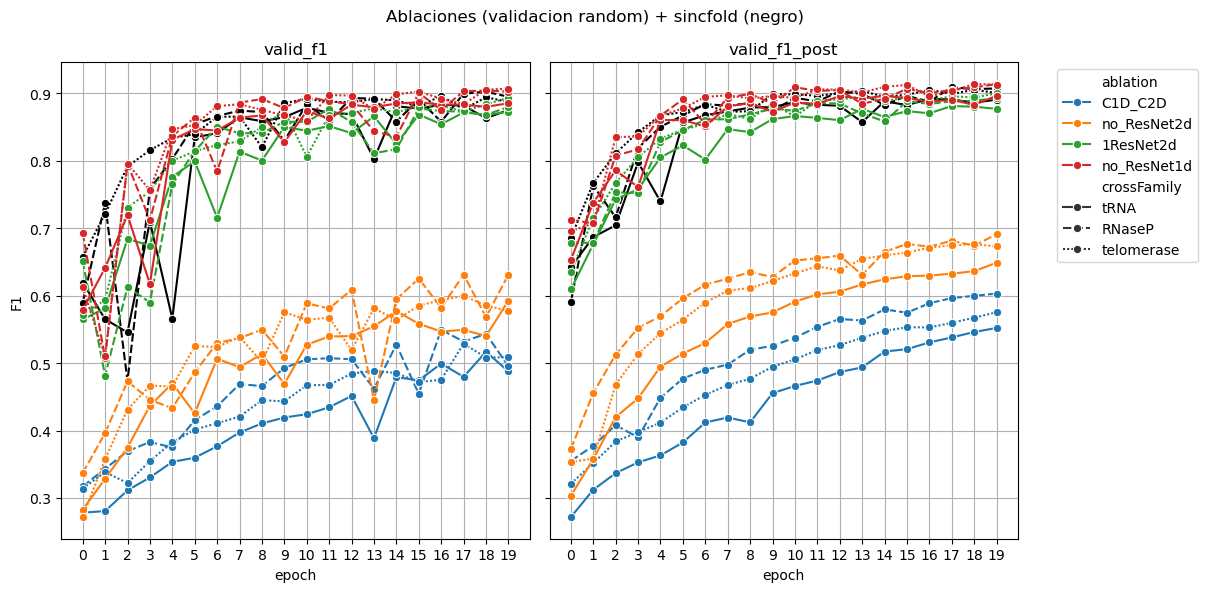

In [198]:
fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True)

# .query('ablation not in ["1ResNet2d", "no_ResNet1d"]')
sns.lineplot(data=train_log_with_valid.query('ablation == "sincfold"'), x='epoch' ,y='valid_f1', style='crossFamily',color='black', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=train_log_with_valid.query('ablation == "sincfold"'), x='epoch' ,y='valid_f1_post', style='crossFamily',color='black', marker='o', ax=axes[1], legend=None) 
sns.lineplot(data=df_logs, x='epoch' ,y='valid_f1',hue='ablation', style='crossFamily', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=df_logs, x='epoch' ,y='valid_f1_post',hue='ablation', style='crossFamily', marker='o', ax=axes[1])

for ax in axes: ax.grid()
for ax in axes: ax.set_xticks(range(20))
axes[0].set_ylabel('F1')
axes[0].set_title('valid_f1')
axes[1].set_title('valid_f1_post')
axes[1].legend(bbox_to_anchor=(1.4,1))
fig.suptitle('Ablaciones (validacion random) + sincfold (negro)')
fig.tight_layout()
plt.show()

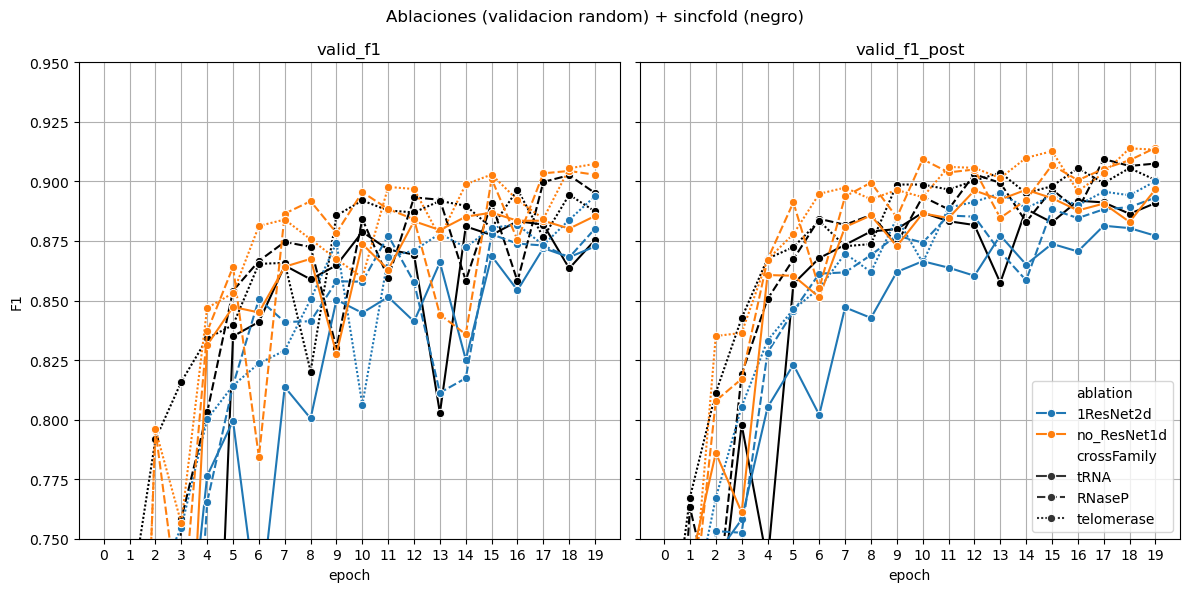

In [199]:
fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True,sharex=True)

# .query('ablation not in ["1ResNet2d", "no_ResNet1d"]')
sns.lineplot(data=train_log_with_valid.query('ablation == "sincfold"'), x='epoch' ,y='valid_f1', style='crossFamily',color='black', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=train_log_with_valid.query('ablation == "sincfold"'), x='epoch' ,y='valid_f1_post', style='crossFamily',color='black', marker='o', ax=axes[1], legend=None) 
df = df_logs.query('ablation in ["1ResNet2d", "no_ResNet1d"]')
sns.lineplot(data=df, x='epoch' ,y='valid_f1',hue='ablation', style='crossFamily', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=df, x='epoch' ,y='valid_f1_post',hue='ablation', style='crossFamily', marker='o', ax=axes[1])

for ax in axes: ax.grid()
for ax in axes: ax.set_xticks(range(20))
axes[0].set_ylim([0.75,0.95])
# axes[0].set_xlim([4.9,10.1])
axes[0].set_ylabel('F1')
axes[0].set_title('valid_f1')
axes[1].set_title('valid_f1_post')
# axes[1].legend(bbox_to_anchor=(1,1))
fig.suptitle('Ablaciones (validacion random) + sincfold (negro)')
fig.tight_layout()
plt.show()

## Comparacion en el error de validacion entre el dataset random y el dataset de test

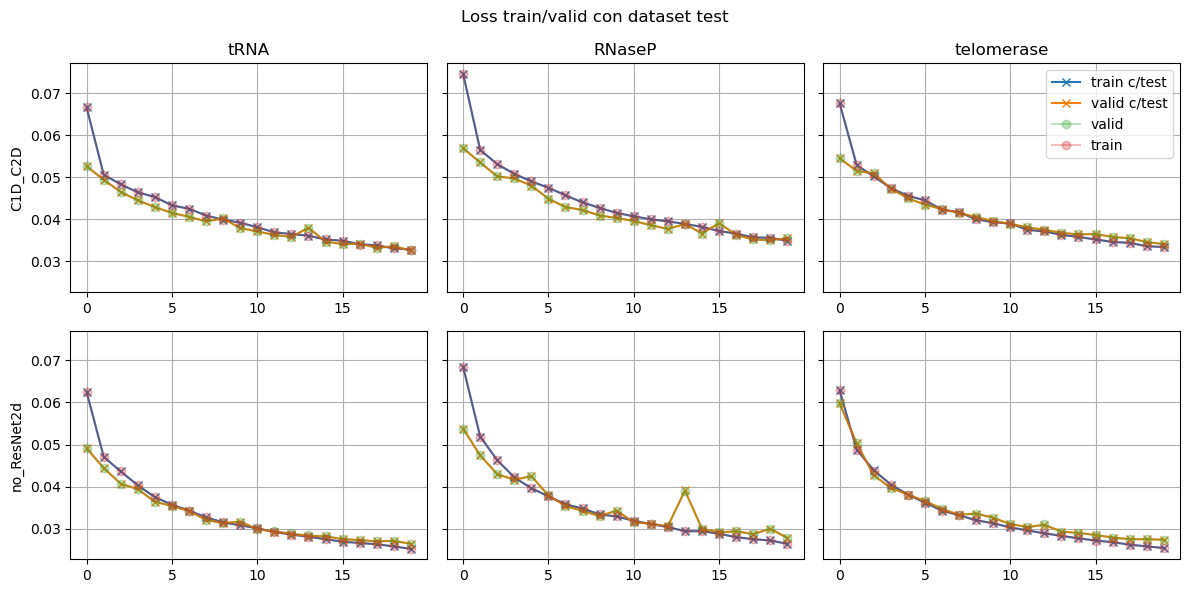

In [211]:
data = df_logs
data_valid = train_log_with_valid
ab = ["C1D_C2D", "no_ResNet2d"]
cf = data.crossFamily.unique()
fig, axes = plt.subplots(len(ab),len(cf), figsize=(12,6), sharey=True)
for i,a in enumerate(ab):
    axes[i,0].set_ylabel(a)
    for j,f in enumerate(cf):
        axes[0,j].set_title(f)
        d = data.query('ablation == @a & crossFamily == @f')        
        dv = data_valid.query('ablation == @a & crossFamily == @f')
        axes[i,j].plot(dv.epoch, dv.train_loss, marker='x', label='train c/test')
        axes[i,j].plot(dv.epoch, dv.valid_loss, marker='x', label='valid c/test')
        axes[i,j].plot(d.epoch, d.valid_loss, marker='o', label='valid', alpha=0.3)
        axes[i,j].plot(d.epoch, d.train_loss, marker='o', label='train', alpha=0.3)

        axes[i,j].grid()
axes[0,-1].legend()        
fig.suptitle('Loss train/valid con dataset test')
fig.tight_layout()

/tmp/ipykernel_4701/569200653.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['train_diff'] = df1['train_loss'] - df2['train_loss']
/tmp/ipykernel_4701/569200653.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['valid_diff'] = df1['valid_loss'] - df2['valid_loss']


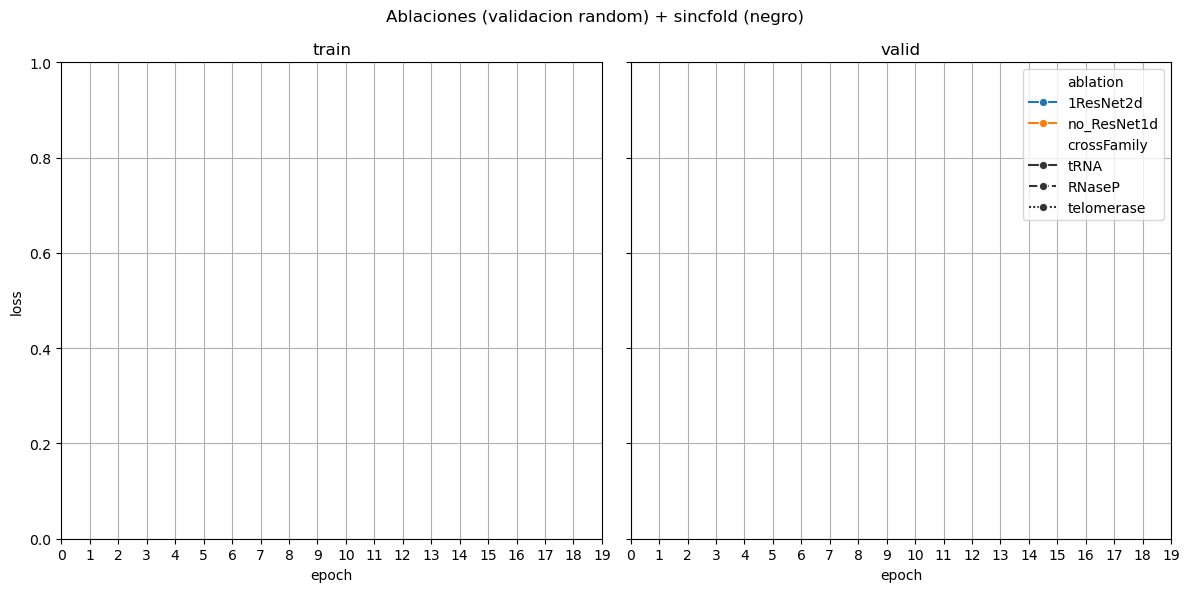

In [201]:
fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True,sharex=True)


df1 = df_logs.query('ablation in ["C1D_C2D", "no_ResNet2d"]')
df2 = train_log_with_valid.query('ablation in ["C1D_C2D", "no_ResNet2d"]')
df['train_diff'] = df1['train_loss'] - df2['train_loss']
df['valid_diff'] = df1['valid_loss'] - df2['valid_loss']


sns.lineplot(data=df, x='epoch' ,y='train_diff',hue='ablation', style='crossFamily', marker='o', ax=axes[0], legend=None)
sns.lineplot(data=df, x='epoch' ,y='valid_diff',hue='ablation', style='crossFamily', marker='o', ax=axes[1])




for ax in axes: ax.grid()
for ax in axes: ax.set_xticks(range(20)) 
axes[0].set_ylabel('loss')
axes[0].set_title('train')
axes[1].set_title('valid')
# axes[1].legend(bbox_to_anchor=(1,1))
fig.suptitle('Ablaciones (validacion random) + sincfold (negro)')
fig.tight_layout()
plt.show()

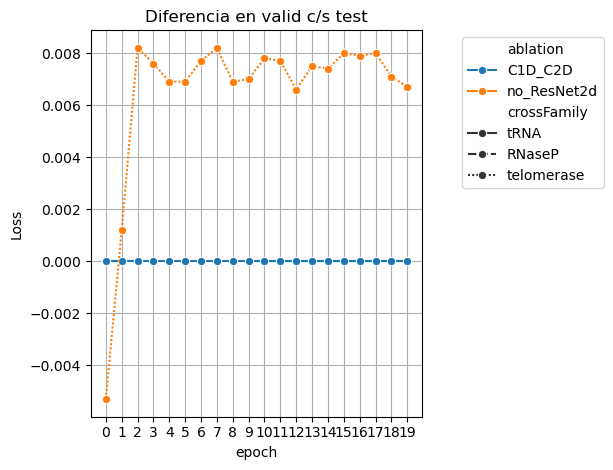

In [202]:
train_log_with_valid['diff'] = df_logs.query('ablation in ["C1D_C2D","no_ResNet_d"] ')['valid_loss'] - train_log_with_valid.query('ablation in ["C1D_C2D","no_ResNet2d"]')['valid_loss']

fig, ax = plt.subplots()
sns.lineplot(data=train_log_with_valid.query('ablation != "sincfold"'), x='epoch' ,y='diff',hue='ablation', style='crossFamily', marker='o', ax=ax)
ax.grid()
ax.set_xticks(range(20))
ax.set_ylabel('Loss')
ax.set_title('Diferencia en valid c/s test')
ax.legend(bbox_to_anchor=(1.1,1))
fig.tight_layout()
plt.show()

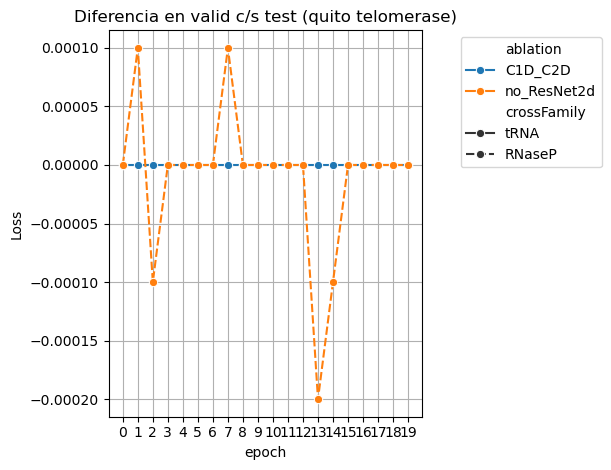

In [203]:
train_log_with_valid['diff'] = df_logs.query('ablation in ["C1D_C2D","no_ResNet2d"] & crossFamily != "telomerase"')['valid_loss'] - train_log_with_valid.query('ablation in ["C1D_C2D","no_ResNet2d"] & crossFamily != "telomerase"')['valid_loss']

fig, ax = plt.subplots()
sns.lineplot(data=train_log_with_valid.query('ablation != "sincfold" & crossFamily != "telomerase"'), x='epoch' ,y='diff',hue='ablation', style='crossFamily', marker='o', ax=ax)
ax.grid()
ax.set_xticks(range(20))
ax.set_ylabel('Loss')
ax.set_title('Diferencia en valid c/s test (quito telomerase)')
ax.legend(bbox_to_anchor=(1.1,1))
fig.tight_layout()
plt.show()